# Timeseries of Sweeps

## Imports

In [1]:
import warnings

import cartopy.crs as ccrs
import cmweather  # noqa
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from open_radar_data import DATASETS

import xradar as xd

warnings.filterwarnings("ignore")

## Access Radar Data from the Open Radar Data Package

In [2]:
radar_files = [
    "gucxprecipradarcmacppiS2.c1.20220314.021559.nc",
    "gucxprecipradarcmacppiS2.c1.20220314.024239.nc",
    "gucxprecipradarcmacppiS2.c1.20220314.025840.nc",
]
files = [DATASETS.fetch(file) for file in radar_files]

## Read the Data using Xradar
We can read the data into xradar by using the `xr.open_mfdataset` function, but first, we need to align the angles of the different radar volumes.

In [3]:
def fix_angle(ds):
    """
    Aligns the radar volumes
    """
    ds["time"] = ds.time.load()  # Convert time from dask to numpy

    start_ang = 0  # Set consistent start/end values
    stop_ang = 360

    # Find the median angle resolution
    angle_res = ds.azimuth.diff("azimuth").median()

    # Determine whether the radar is spinning clockwise or counterclockwise
    median_diff = ds.azimuth.diff("time").median()
    ascending = median_diff > 0
    direction = 1 if ascending else -1

    # first find exact duplicates and remove
    ds = xd.util.remove_duplicate_rays(ds)

    # second reindex according to retrieved parameters
    ds = xd.util.reindex_angle(
        ds, start_ang, stop_ang, angle_res, direction, method="nearest"
    )

    ds = ds.expand_dims("volume_time")  # Expand for volumes for concatenation

    ds["volume_time"] = [np.nanmin(ds.time.values)]

    return ds

In [4]:
# Concatenate in xarray ds
ds = xr.open_mfdataset(
    files,
    preprocess=fix_angle,
    engine="cfradial1",
    group="sweep_0",
    concat_dim="volume_time",
    combine="nested",
)
ds

<xarray.Dataset> Size: 2GB
Dimensions:                                   (volume_time: 3, azimuth: 1130,
                                               range: 2004)
Coordinates:
  * range                                     (range) float32 8kB 306.9 ... 4...
  * azimuth                                   (azimuth) float32 5kB 0.1593 .....
  * volume_time                               (volume_time) datetime64[ns] 24B ...
    time                                      (volume_time, azimuth) datetime64[ns] 27kB ...
    elevation                                 (volume_time, azimuth) float64 27kB ...
    latitude                                  float64 8B 38.9
    longitude                                 float64 8B -106.9
    altitude                                  float64 8B 3.149e+03
Data variables: (12/37)
    DBZ                                       (volume_time, azimuth, range) float64 54MB dask.array<chunksize=(1, 1130, 668), meta=np.ndarray>
    VEL                                       (volume_time, azimuth, range) float64 54MB dask.array<chunksize=(1, 1130, 668), meta=np.ndarray>
    WIDTH                                     (volume_time, azimuth, range) float64 54MB dask.array<chunksize=(1, 1130, 668), meta=np.ndarray>
    ZDR                                       (volume_time, azimuth, range) float64 54MB dask.array<chunksize=(1, 1130, 668), meta=np.ndarray>
    PHIDP                                     (volume_time, azimuth, range) float64 54MB dask.array<chunksize=(1, 1130, 668), meta=np.ndarray>
    RHOHV                                     (volume_time, azimuth, range) float64 54MB dask.array<chunksize=(1, 1130, 668), meta=np.ndarray>
    ...                                        ...
    snow_rate_m2009_1                         (volume_time, azimuth, range) float64 54MB dask.array<chunksize=(1, 1130, 668), meta=np.ndarray>
    snow_rate_m2009_2                         (volume_time, azimuth, range) float64 54MB dask.array<chunksize=(1, 1130, 668), meta=np.ndarray>
    sweep_number                              (volume_time) int32 12B 0 0 0
    sweep_fixed_angle                         (volume_time) float32 12B 5.988...
    sweep_mode                                (volume_time) <U188 2kB 'azimut...
    nyquist_velocity                          (volume_time, azimuth) float64 27kB dask.array<chunksize=(1, 1130), meta=np.ndarray>

## Visualize the Dataset
Now that we have our dataset, we can visualize it.

We need to georeference first, then plot it!

### Georeference the Dataset

In [5]:
ds = ds.xradar.georeference()
ds

<xarray.Dataset> Size: 2GB
Dimensions:                                   (volume_time: 3, azimuth: 1130,
                                               range: 2004)
Coordinates:
  * range                                     (range) float32 8kB 306.9 ... 4...
  * azimuth                                   (azimuth) float32 5kB 0.1593 .....
  * volume_time                               (volume_time) datetime64[ns] 24B ...
    time                                      (volume_time, azimuth) datetime64[ns] 27kB ...
    elevation                                 (volume_time, azimuth) float64 27kB ...
    latitude                                  float64 8B 38.9
    longitude                                 float64 8B -106.9
    altitude                                  float64 8B 3.149e+03
    crs_wkt                                   int64 8B 0
    x                                         (azimuth, range, volume_time) float64 54MB ...
    y                                         (azimuth, range, volume_time) float64 54MB ...
    z                                         (volume_time, azimuth, range) float64 54MB ...
Data variables: (12/37)
    DBZ                                       (volume_time, azimuth, range) float64 54MB dask.array<chunksize=(1, 1130, 668), meta=np.ndarray>
    VEL                                       (volume_time, azimuth, range) float64 54MB dask.array<chunksize=(1, 1130, 668), meta=np.ndarray>
    WIDTH                                     (volume_time, azimuth, range) float64 54MB dask.array<chunksize=(1, 1130, 668), meta=np.ndarray>
    ZDR                                       (volume_time, azimuth, range) float64 54MB dask.array<chunksize=(1, 1130, 668), meta=np.ndarray>
    PHIDP                                     (volume_time, azimuth, range) float64 54MB dask.array<chunksize=(1, 1130, 668), meta=np.ndarray>
    RHOHV                                     (volume_time, azimuth, range) float64 54MB dask.array<chunksize=(1, 1130, 668), meta=np.ndarray>
    ...                                        ...
    snow_rate_m2009_1                         (volume_time, azimuth, range) float64 54MB dask.array<chunksize=(1, 1130, 668), meta=np.ndarray>
    snow_rate_m2009_2                         (volume_time, azimuth, range) float64 54MB dask.array<chunksize=(1, 1130, 668), meta=np.ndarray>
    sweep_number                              (volume_time) int32 12B 0 0 0
    sweep_fixed_angle                         (volume_time) float32 12B 5.988...
    sweep_mode                                (volume_time) <U188 2kB 'azimut...
    nyquist_velocity                          (volume_time, azimuth) float64 27kB dask.array<chunksize=(1, 1130), meta=np.ndarray>

### Extract the geoaxis information

In [6]:
proj_crs = xd.georeference.get_crs(ds)
cart_crs = ccrs.Projection(proj_crs)

### Use the FacetGrid to visualize

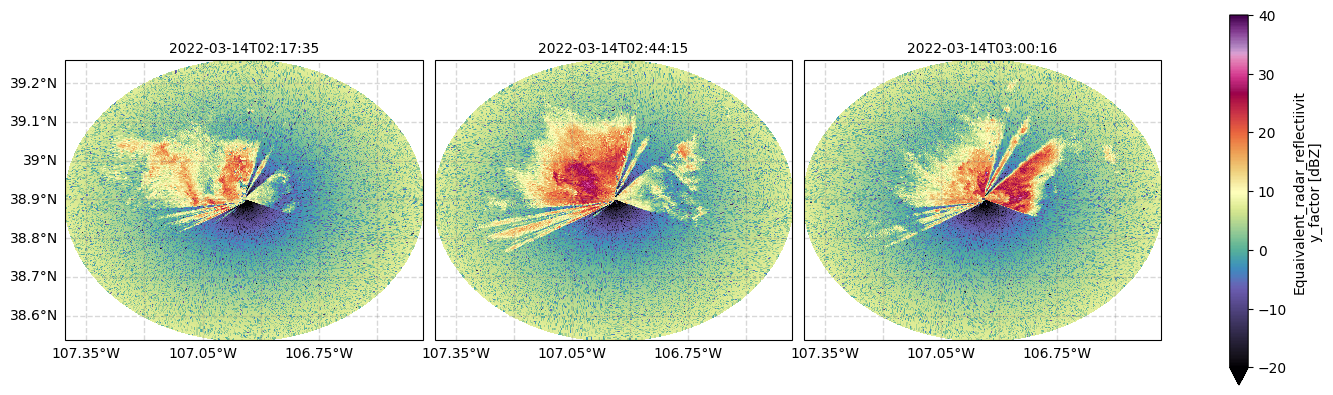

In [7]:
# Create our facets grid
fg = ds.DBZ.plot.pcolormesh(
    x="x",
    y="y",
    vmin=-20,
    vmax=40,
    cmap="ChaseSpectral",
    col="volume_time",
    edgecolors="face",
    figsize=(14, 4),
    transform=cart_crs,
    subplot_kws={"projection": ccrs.PlateCarree()},
)
# Set the title
fg.set_titles("{value}")

# Fix the geo-axes labels
first_axis = True
for ax in fg.axes.flat:
    ax.coastlines()
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=1,
        color="gray",
        alpha=0.3,
        linestyle="--",
    )
    plt.gca().xaxis.set_major_locator(plt.NullLocator())
    gl.top_labels = False
    gl.right_labels = False
    if first_axis:
        gl.left_labels = True
    else:
        gl.left_labels = False
    first_axis = False